In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
n_strip = 12
n_blob = 100
# Class 0
x0_1 = np.hstack([
np.random.normal(scale=0.6, size=(n_strip, 1)),
np.random.uniform(0.3, 0.8, size=(n_strip, 1))
])
x0_2 = np.random.multivariate_normal(
mean=[0, 10],
cov=np.array([[4, 3.5], [3.5, 4]]),
size=n_blob
)
X0 = np.vstack([x0_1, x0_2])
y0 = np.zeros(n_strip + n_blob)
# Class 1
x1_1 = np.hstack([
np.random.normal(scale=0.6, size=(n_strip, 1)),
np.random.uniform(-0.8,-0.3, size=(n_strip, 1))
])
x1_2 = np.random.multivariate_normal(
mean=[0,-10],
cov=np.array([[4, 3.5], [3.5, 4]]),
size=n_blob
)
X1 = np.vstack([x1_1, x1_2])
y1 = np.ones(n_strip + n_blob)
X = np.vstack([X0, X1])
y = np.concatenate([y0, y1])

In [2]:
from sklearn.svm import *
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *
from sklearn.model_selection import train_test_split

In [4]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)


In [12]:
x_scaled=scaler.transform(X)

In [16]:
svm=SVC(kernel='linear')
svm.fit(X_train_scaled, y_train)
lr=LogisticRegression()
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [7]:
import numpy as np
import matplotlib.pyplot as plt


def plot_decision_regions(X, y, classifier, title):
    # Setup marker generator and color map
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = classifier.predict(np.array([xx.ravel(), yy.ravel()]).T)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()



In [19]:


def plot_svc_details(X, y, model):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)

    # 1. Plot the Decision Boundary and Margins
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # get_decision_function returns the distance from the hyperplane
    Z = model.decision_function(xy).reshape(XX.shape)

    # Plot decision boundary (Z=0) and margins (Z=-1 and Z=1)
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # 2. Highlight Support Vectors
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='k', label='Support Vectors')

    plt.title("Linear SVM: Hyperplane, Margins, and Support Vectors")
    plt.legend()
    plt.show()



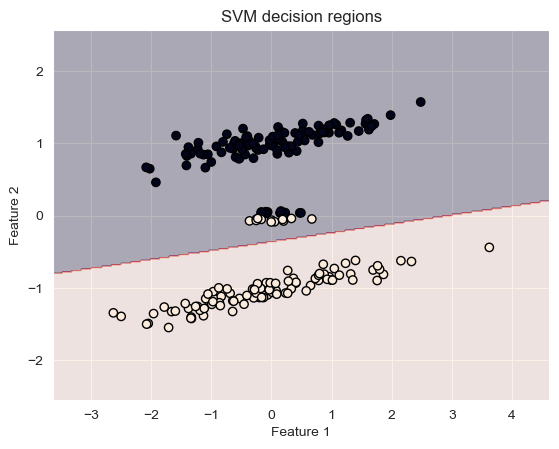

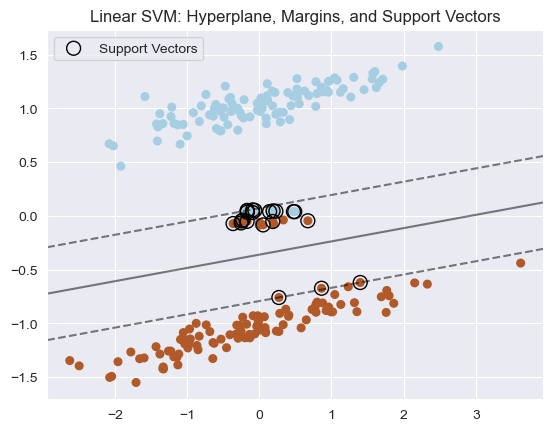

In [20]:
plot_decision_regions(x_scaled, y, classifier=svm,title='SVM decision regions')
plot_svc_details(x_scaled,y,svm)

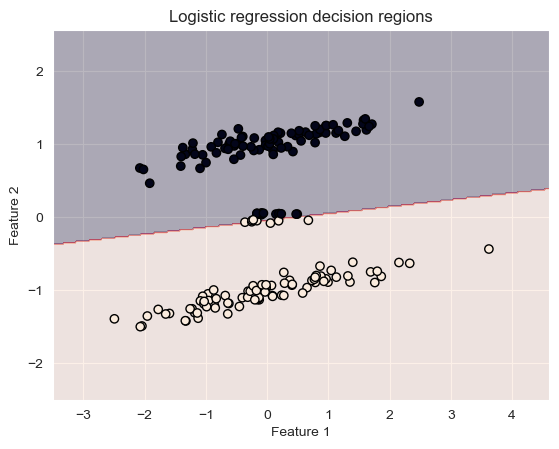

In [18]:
plot_decision_regions(X_train_scaled, y_train, classifier=lr,title='Logistic regression decision regions')


# Boundaries comparison
logistic regression fits a straight line, cutting through the cluster of middle points, while the svm with  linear kernel has a boundary where the middle points are all within one prediction group.
question answers:
- (a) the boundaries are different because of different loss functions are optimized and svm "cares" about less points (only the support vectors) than lr
- (b) all misclassified and those that are closest to the decision boundary.
- (c) no, as can be seen on the plot above
- (d) no, svm is a pure optimizer of loss function, without posterior estimations
- (e) The SVM uses Hinge Loss, which for correctly classified points far enough from the margin returns error equal 0.
- (f) the greater the value of parameter C, the smaller the margin, and in this specific case the boundary has lower angle.
- (g) support vector numbers are listed below, but with greater C there are less support vectors

For C=0.01: Total Support Vectors = 119


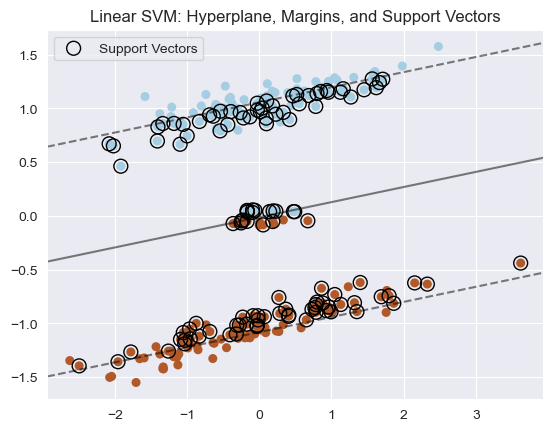

For C=0.1: Total Support Vectors = 33


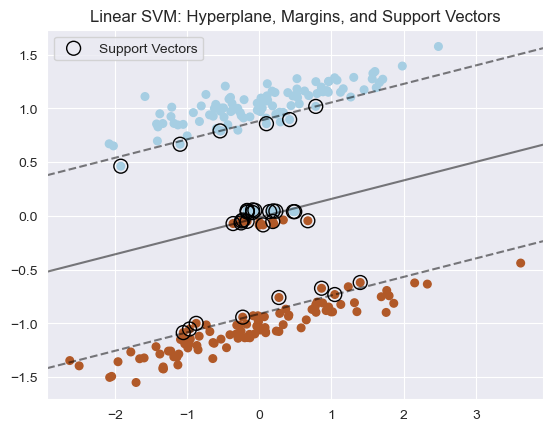

For C=1: Total Support Vectors = 22


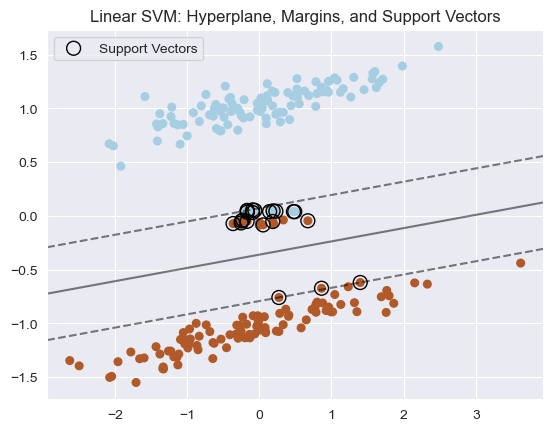

For C=10: Total Support Vectors = 17


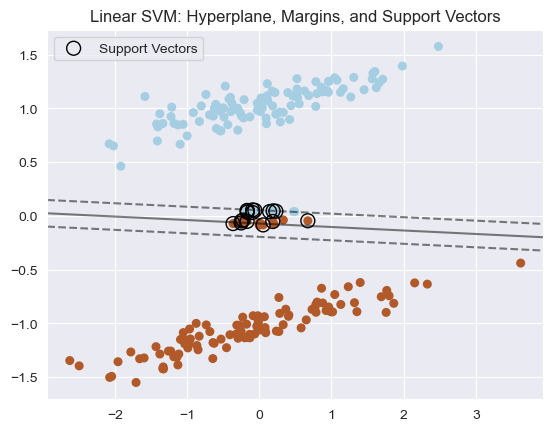

For C=100: Total Support Vectors = 7


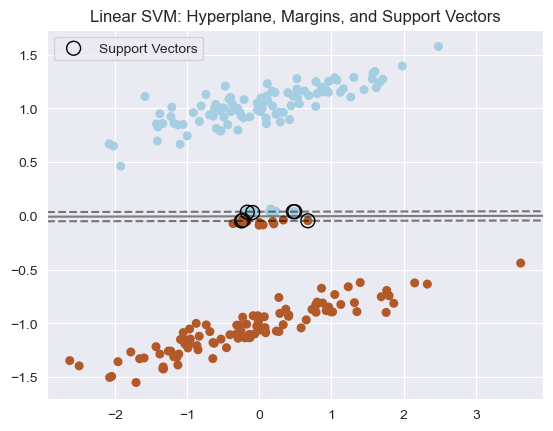

In [24]:
cs = [0.01, 0.1, 1, 10, 100]

for c in cs:
    svmc = SVC(C=c, kernel='linear')
    svmc.fit(X_train_scaled, y_train)
    num_sv = svmc.n_support_.sum()
    print(f"For C={c}: Total Support Vectors = {num_sv}")
    plot_svc_details(x_scaled, y, svmc)

# Kernel SVM

In [25]:
from sklearn.datasets import make_moons
X, y = make_moons(
n_samples=300,
noise=0.25,
random_state=123
)

In [26]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
log_reg = LogisticRegression()
poly2_reg = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2)),
    ("logistic_regression", LogisticRegression())
])
poly3_reg = Pipeline([
    ("poly_features", PolynomialFeatures(degree=3)),
    ("logistic_regression", LogisticRegression())
])

svm_linear = SVC(kernel="linear")
svm_poly2 = SVC(kernel="poly", degree=2, C=10, coef0=10)
svm_poly3 = SVC(kernel="poly", degree=3, C=10, coef0=10)
svm_poly4 = SVC(kernel="poly", degree=4, C=10, coef0=10)
svm_rbf = SVC(kernel="rbf")

In [28]:
log_reg.fit(x_train, y_train)
poly2_reg.fit(x_train, y_train)
poly3_reg.fit(x_train, y_train)
svm_linear.fit(x_train, y_train)
svm_poly2.fit(x_train, y_train)
svm_poly3.fit(x_train, y_train)
svm_poly4.fit(x_train, y_train)
svm_rbf.fit(x_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [29]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": log_reg,
    "LogReg Poly 2": poly2_reg,
    "LogReg Poly 3": poly3_reg,
    "Linear SVM": svm_linear,
    "SVM Poly 2": svm_poly2,
    "SVM Poly 3": svm_poly3,
    "SVM Poly 4": svm_poly4,
    "SVM RBF": svm_rbf
}

print(f"{'Model Name':<20} | {'Train Acc':<10} | {'Test Acc':<10}")
print("-" * 45)

for name, clf in models.items():
    train_pred = clf.predict(x_train)
    test_pred = clf.predict(x_test)
        train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print(f"{name:<20} | {train_acc:.4f}    | {test_acc:.4f}")

Model Name           | Train Acc  | Test Acc  
---------------------------------------------
Logistic Regression  | 0.8042    | 0.8833
LogReg Poly 2        | 0.8167    | 0.8833
LogReg Poly 3        | 0.9125    | 0.9167
Linear SVM           | 0.8167    | 0.9333
SVM Poly 2           | 0.8167    | 0.8833
SVM Poly 3           | 0.9583    | 0.9167
SVM Poly 4           | 0.9583    | 0.9333
SVM RBF              | 0.9333    | 0.9167


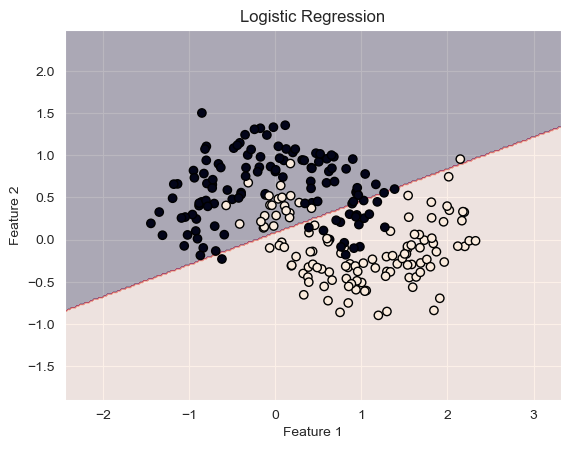

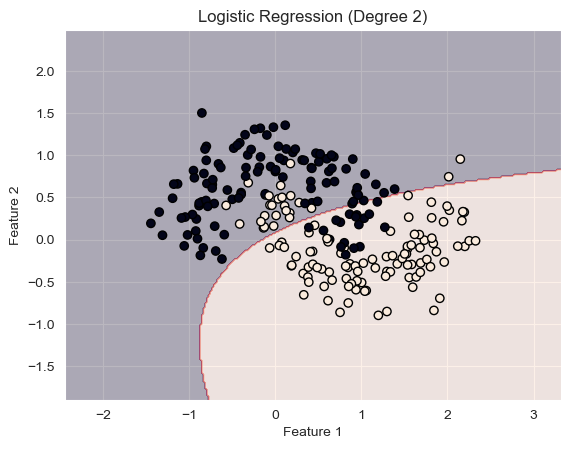

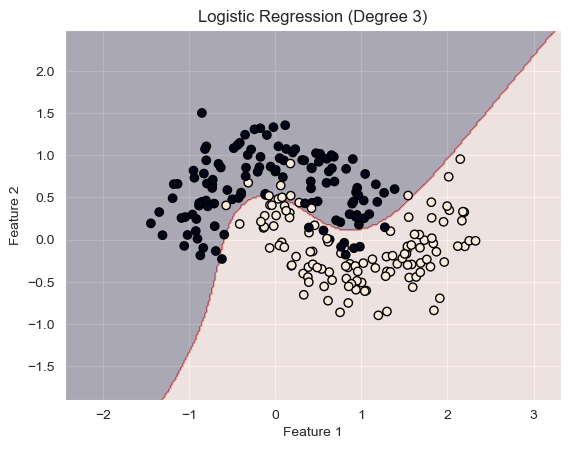

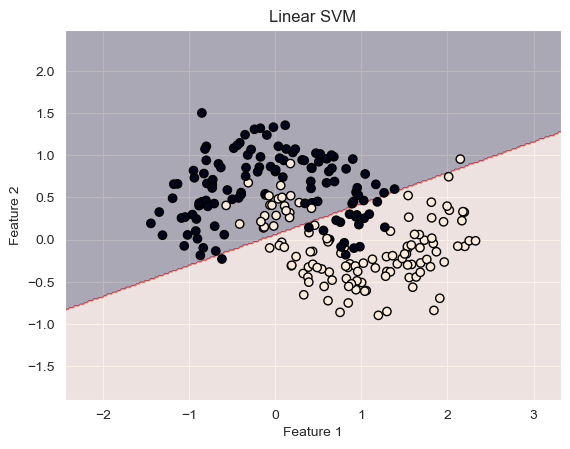

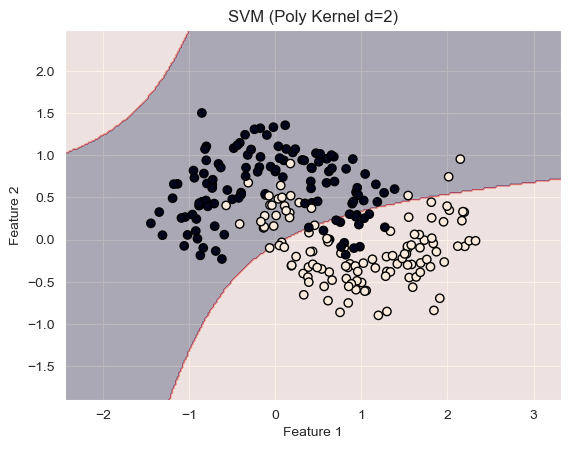

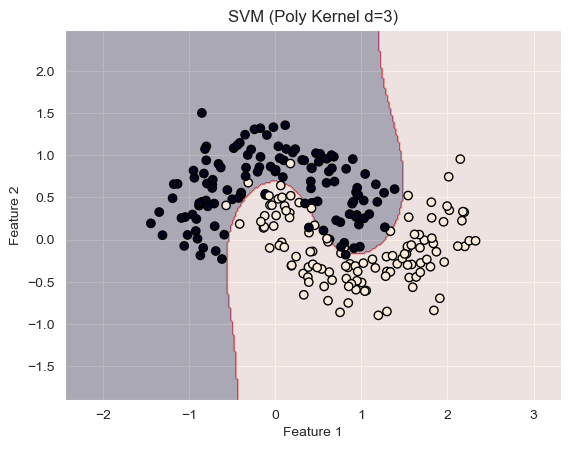

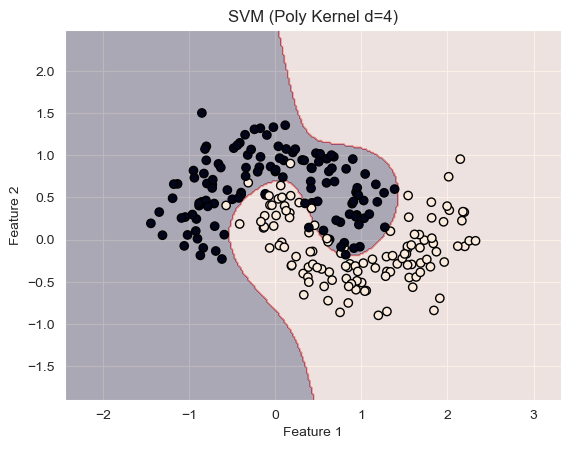

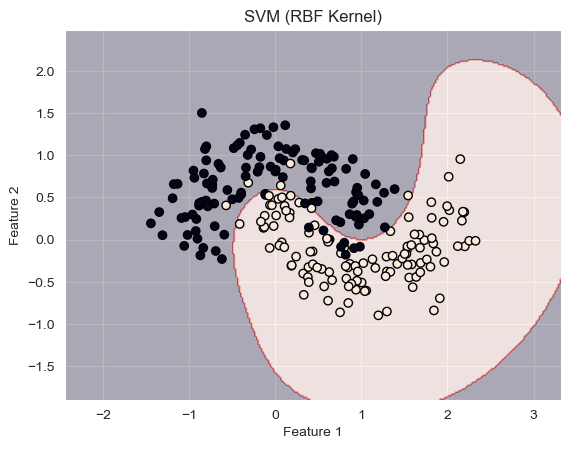

In [30]:
models_to_plot = [
    (log_reg, "Logistic Regression"),
    (poly2_reg, "Logistic Regression (Degree 2)"),
    (poly3_reg, "Logistic Regression (Degree 3)"),
    (svm_linear, "Linear SVM"),
    (svm_poly2, "SVM (Poly Kernel d=2)"),
    (svm_poly3, "SVM (Poly Kernel d=3)"),
    (svm_poly4, "SVM (Poly Kernel d=4)"),
    (svm_rbf, "SVM (RBF Kernel)")
]

for clf, name in models_to_plot:
    X_plot = x_train.values if hasattr(x_train, 'values') else x_train
    y_plot = y_train.values.ravel() if hasattr(y_train, 'values') else y_train

    plot_decision_regions(X_plot, y_plot, clf, title=name)

# boundary shape comparison:
linear svm and standard lr have linear boundary, and are almost identical, while the models with polynomial kernels tend to have more and more complex shapes of boundaries, depending on the degree, which prove to be generally better because of shape, though degree 4 seems to overfit.

--- RBF SVM with Gamma = 0.01 ---
Training Accuracy: 0.7750
Testing Accuracy:  0.9000


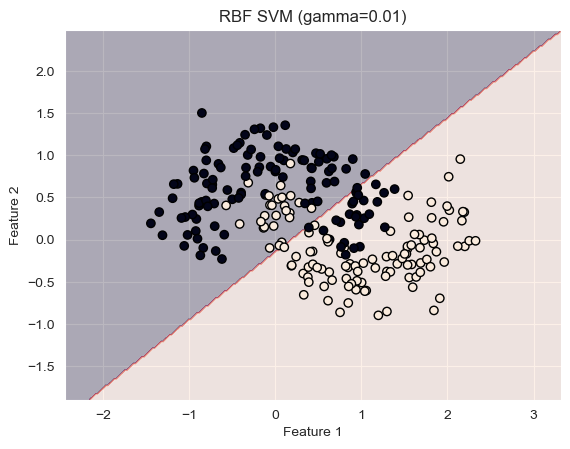

------------------------------
--- RBF SVM with Gamma = 0.1 ---
Training Accuracy: 0.8167
Testing Accuracy:  0.9000


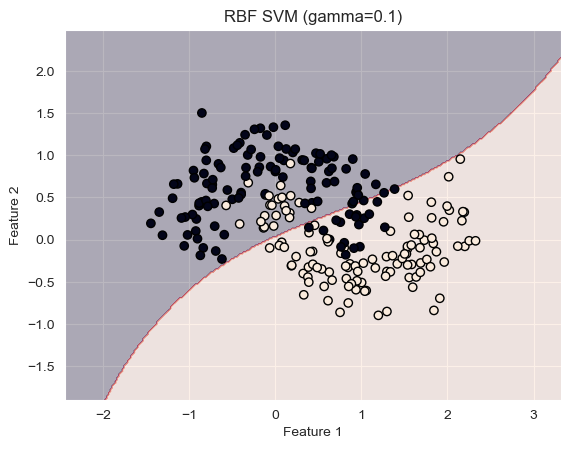

------------------------------
--- RBF SVM with Gamma = 1 ---
Training Accuracy: 0.9333
Testing Accuracy:  0.9167


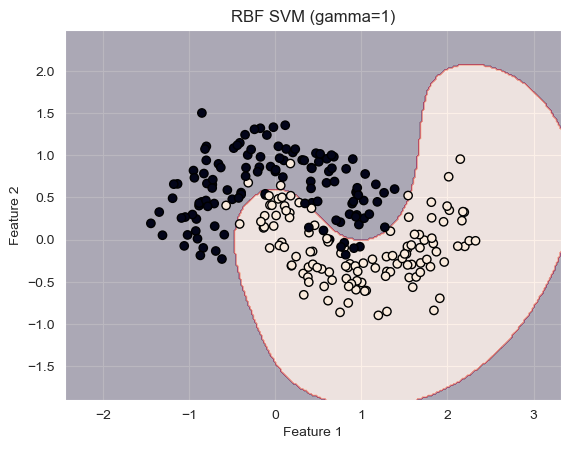

------------------------------
--- RBF SVM with Gamma = 10 ---
Training Accuracy: 0.9625
Testing Accuracy:  0.9000


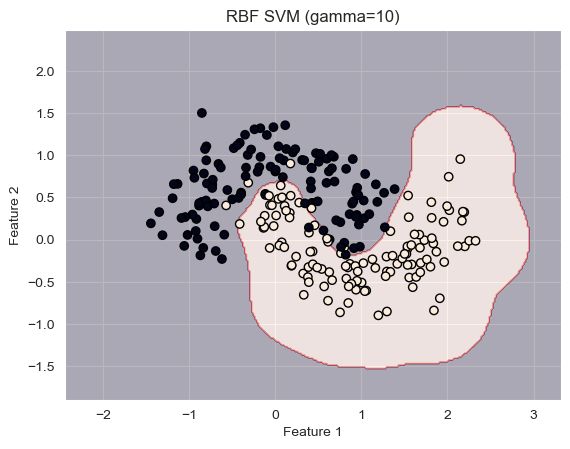

------------------------------
--- RBF SVM with Gamma = 100 ---
Training Accuracy: 0.9792
Testing Accuracy:  0.9167


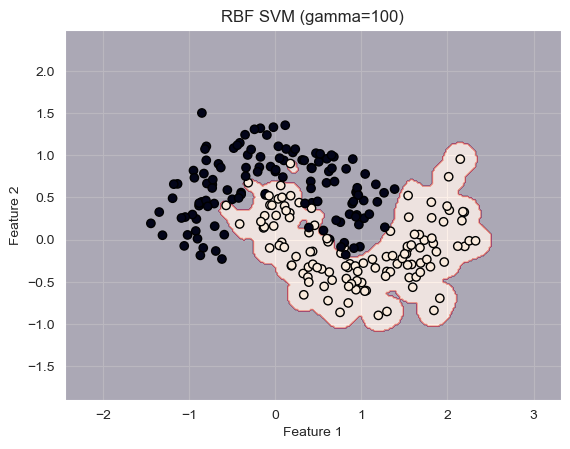

------------------------------


In [31]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

gammas = [0.01, 0.1, 1, 10, 100]

X_train_np = x_train.values if hasattr(x_train, 'values') else x_train
y_train_np = y_train.values.ravel() if hasattr(y_train, 'values') else y_train
X_test_np = x_test.values if hasattr(x_test, 'values') else x_test
y_test_np = y_test.values.ravel() if hasattr(y_test, 'values') else y_test

for g in gammas:
    svm_rbf_gamma = SVC(kernel="rbf", C=1, gamma=g)
    svm_rbf_gamma.fit(X_train_np, y_train_np)

    train_acc = svm_rbf_gamma.score(X_train_np, y_train_np)
    test_acc = svm_rbf_gamma.score(X_test_np, y_test_np)

    print(f"--- RBF SVM with Gamma = {g} ---")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy:  {test_acc:.4f}")

    plot_decision_regions(X_train_np, y_train_np, svm_rbf_gamma, title=f"RBF SVM (gamma={g})")
    print("-" * 30)

# Answers for questions:
- the greater gamma, the more complex the boundary, with gamma=100 the model overfits
- (a) because the classes are not linearly separable
- (b) the result of lr with polynomial with degree 3 is as a well-fitted decision boundary, as it matches the shape of the data, while not overfitting to specific points.
- (c) the rbf kernel allows svm to make the boundary non-linear
- (d) with very small gamma, the kernel acts as if it was just a linear one.
- (e) very large gamma makes the model massivly overfit its boundary
- (f) Both approaches aim to find non-linear decision boundaries by projecting data into higher dimensions, but they differ in how they manage that complexity. Logistic Regression requires explicitly calculating new polynomial features, while SVM uses the Kernel Trick to implicitly handle high-dimensional space more efficiently. Also the standard differences between those approaches are present, such as which points are taken into account and different loss functions.